In [2]:
from coffea.nanoevents import NanoEventsFactory, PFNanoAODSchema
import fastjet
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np

import warnings
warnings.filterwarnings("ignore")

import sys
sys.path.append("/uscms_data/d3/azhou/smeft/hbb-run3/src")
sys.path.append('~/nobackup/smeft/topcoffea')
from hbb.utils import load_samples, get_sum_genweights
#from hbb.processors.categorizer import add_weights, get_dataset_norm
import pickle
import uproot

In [6]:
start0_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start0_5000.root"
start1_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/vbf_rw_start1_5000.root"
powheg_sample = "/uscms/home/azhou/nobackup/smeft/jennet_files/powheg.root"

start0_events = NanoEventsFactory.from_root(
    {start0_sample:"/Events"},
    schemaclass=PFNanoAODSchema,
    mode='eager'
).events()

start1_events = NanoEventsFactory.from_root(
    {start1_sample:"/Events"},
    schemaclass=PFNanoAODSchema,
    mode='eager'
).events()

powheg_events = NanoEventsFactory.from_root(
    {powheg_sample:"/Events"},
    schemaclass=PFNanoAODSchema,
    mode='eager'
).events()

In [4]:
start0_events.fields

['GenJet',
 'event',
 'run',
 'GenJetAK8',
 'EFTfitCoefficients',
 'MET',
 'LHEPart',
 'luminosityBlock',
 'GenIsolatedPhoton',
 'GenMET',
 'WCnames',
 'genWeight',
 'LHEScaleWeight',
 'LHEReweightingWeight',
 'Generator',
 'LHE',
 'PSWeight',
 'GenDressedLepton',
 'bunchCrossing',
 'LHEPdfWeight',
 'LHEWeight',
 'GenVisTau',
 'GenPart',
 'HTXS',
 'GenVtx']

In [18]:
print(start0_events.HTXS.fields)

['njets25', 'njets30', 'stage1_1_cat_pTjet25GeV', 'stage1_1_cat_pTjet30GeV', 'stage1_1_fine_cat_pTjet25GeV', 'stage1_1_fine_cat_pTjet30GeV', 'stage1_2_cat_pTjet25GeV', 'stage1_2_cat_pTjet30GeV', 'stage1_2_fine_cat_pTjet25GeV', 'stage1_2_fine_cat_pTjet30GeV', 'stage_0', 'stage_1_pTjet25', 'stage_1_pTjet30', 'Higgs_pt', 'Higgs_y']


In [ ]:
start0_higgs = start0_events.LHEPart[start0_events.LHEPart.pdgId == 25]
start0_h_pt = start0_higgs.pt


sum weights 1,2:  1073.7292 1566.0093
errors 64.51424 77.9122
1.4584769 ± 0.113774166
[np.int64(277), np.int64(404)]


Text(0.5, 1.0, 'HTXS bins for mjj, powheg')

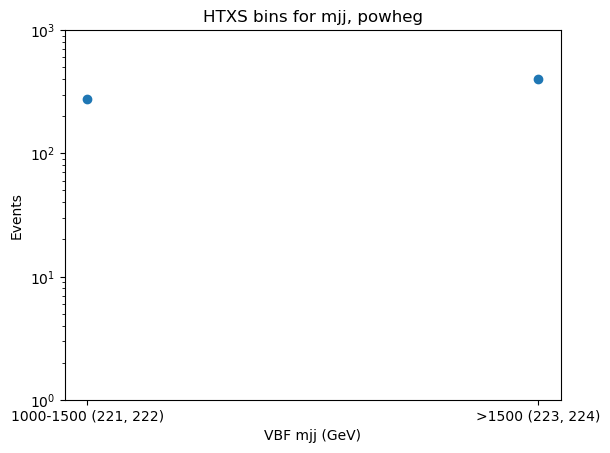

In [8]:
start0_weights = start0_events.genWeight
start1_weights = start1_events.genWeight
powheg_weights = powheg_events.genWeight

VBF_1000_1500=[221, 222]
VBF_GT1500=[223, 224]

start0_htxs_stage2 = start0_events.HTXS["stage1_2_fine_cat_pTjet25GeV"]
start1_htxs_stage2 = start1_events.HTXS["stage1_2_fine_cat_pTjet25GeV"]
powheg_htxs_stage2 = powheg_events.HTXS["stage1_2_fine_cat_pTjet25GeV"]

vbf_htxs_codes = [221, 222, 223, 224]
bin1_codes = [221,222]
bin2_codes = [223,224]

counts_per_code = {}
for htxs_number in vbf_htxs_codes:
    counts_per_code[htxs_number] = np.sum(powheg_htxs_stage2 == htxs_number)

bin1_counts = np.sum(np.isin(powheg_htxs_stage2, bin1_codes))
bin2_counts = np.sum(np.isin(powheg_htxs_stage2, bin2_codes))

#yields
bin1_sum_weights = np.sum(powheg_weights[np.isin(powheg_htxs_stage2, bin1_codes)])
bin2_sum_weights = np.sum(powheg_weights[np.isin(powheg_htxs_stage2, bin2_codes)])

err1 = np.sqrt(np.sum(powheg_weights[np.isin(powheg_htxs_stage2, bin1_codes)]**2))
err2 = np.sqrt(np.sum(powheg_weights[np.isin(powheg_htxs_stage2, bin2_codes)]**2))

print('sum weights 1,2: ', bin1_sum_weights, bin2_sum_weights)
print('errors', err1, err2)

ratio = bin2_sum_weights / bin1_sum_weights
ratio_err = ratio * np.sqrt((err1/bin1_sum_weights)**2 + (err2/bin2_sum_weights)**2)
print(ratio, '±', ratio_err)

#print(set(start0_htxs_stage2))

# vbf_mask = np.isin(start0_htxs_stage2, vbf_htxs_codes)
# vbf_start0_htxs_stage2 = start0_htxs_stage2[vbf_mask]
# vbf_start0_weights = start0_weights[vbf_mask]

counts = [bin1_counts, bin2_counts]
print(counts)
labels = ['1000-1500 (221, 222)', '>1500 (223, 224)']

errors = np.sqrt(counts)

plt.errorbar(labels, counts, yerr = errors, fmt='o')
plt.yscale('log')
plt.ylim(1, 1000)
plt.xlabel("VBF mjj (GeV)")
plt.ylabel("Events")
plt.title("HTXS bins for mjj, powheg")

{np.int32(200), np.int32(201), np.int32(202), np.int32(203), np.int32(204), np.int32(205), np.int32(206), np.int32(207), np.int32(208), np.int32(209), np.int32(210), np.int32(211), np.int32(212), np.int32(213), np.int32(214), np.int32(215), np.int32(216), np.int32(217), np.int32(218), np.int32(219), np.int32(220), np.int32(221), np.int32(222), np.int32(223), np.int32(224)}
166
[np.int64(160), np.int64(166)]


Text(0.5, 1.0, 'HTXS bins for mjj, start1')

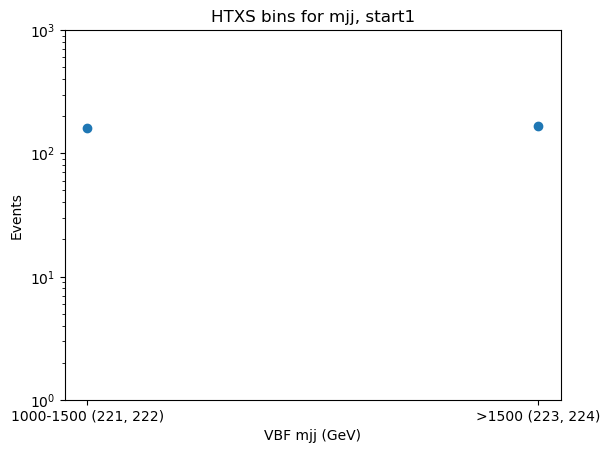

In [63]:
start0_weights = start0_events.genWeight
start1_weights = start1_events.genWeight

VBF_1000_1500=[221, 222]
VBF_GT1500=[223, 224]

start0_htxs_stage2 = start0_events.HTXS["stage1_2_fine_cat_pTjet25GeV"]
start1_htxs_stage2 = start1_events.HTXS["stage1_2_fine_cat_pTjet25GeV"]


vbf_htxs_codes = [221, 222, 223, 224]
bin1_codes = [221,222]
bin2_codes = [223,224]

counts_per_code = {}
for htxs_number in vbf_htxs_codes:
    counts_per_code[htxs_number] = np.sum(start1_htxs_stage2 == htxs_number)

bin1_counts = np.sum(np.isin(start1_htxs_stage2, bin1_codes))
bin2_counts = np.sum(np.isin(start1_htxs_stage2, bin2_codes))

print(set(start1_htxs_stage2))

print(bin2_counts)

# vbf_mask = np.isin(start0_htxs_stage2, vbf_htxs_codes)
# vbf_start0_htxs_stage2 = start0_htxs_stage2[vbf_mask]
# vbf_start0_weights = start0_weights[vbf_mask]

counts = [bin1_counts, bin2_counts]
print(counts)
labels = ['1000-1500 (221, 222)', '>1500 (223, 224)']

errors = np.sqrt(counts)

plt.errorbar(labels, counts, yerr = errors, fmt='o')
plt.yscale('log')
plt.ylim(1, 1000)
plt.xlabel("VBF mjj (GeV)")
plt.ylabel("Events")
plt.title("HTXS bins for mjj, start1")

Text(0.5, 1.0, 'HTXS Higgs_pt')

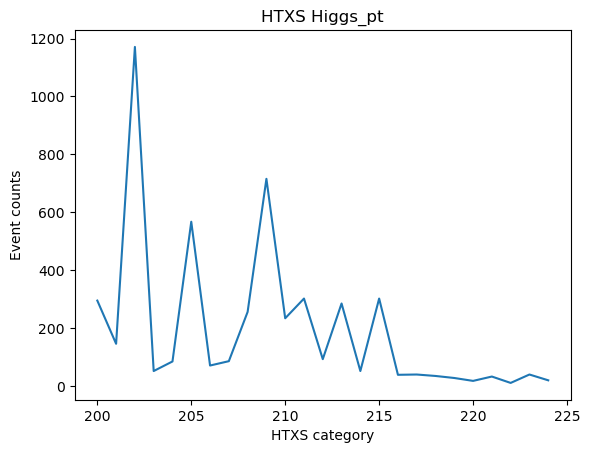

In [50]:
start0_weights = start0_events.genWeight

start0_htxs_stage2 = start0_events.HTXS["stage1_2_fine_cat_pTjet25GeV"]

vbf_htxs_codes = np.arange(200, 211)

mjjs = ak.to_numpy(start0_htxs_stage2)

codes, counts = np.unique(mjjs, return_counts=True)

plt.plot(codes, counts)

plt.xlabel("HTXS category")
plt.ylabel("Event counts")
plt.title("HTXS Higgs_pt")


# "QQ2HQQ_FWDH":200,
# "QQ2HQQ_0J":201,
# "QQ2HQQ_1J":202,
# "QQ2HQQ_GE2J_MJJ_0_60_PTHJJ_0_25":203,
# "QQ2HQQ_GE2J_MJJ_60_120_PTHJJ_0_25":204,
# "QQ2HQQ_GE2J_MJJ_120_350_PTHJJ_0_25":205,
# "QQ2HQQ_GE2J_MJJ_0_60_PTHJJ_GT25":206,
# "QQ2HQQ_GE2J_MJJ_60_120_PTHJJ_GT25":207,
# "QQ2HQQ_GE2J_MJJ_120_350_PTHJJ_GT25":208,
# "QQ2HQQ_GE2J_MJJ_350_700_PTH_0_200_PTHJJ_0_25":209,
# "QQ2HQQ_GE2J_MJJ_350_700_PTH_0_200_PTHJJ_GT25":210,


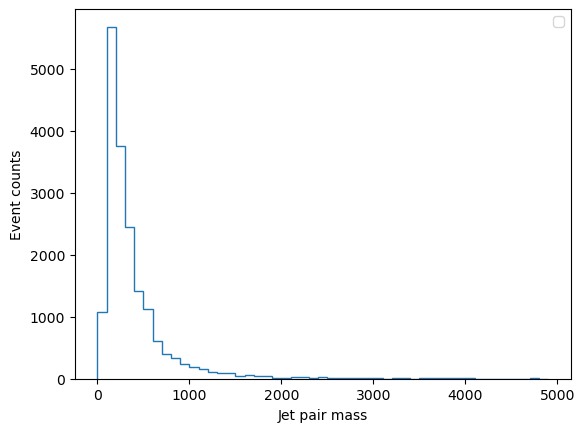

In [47]:
start0_mjj_mask = ak.num(start0_events.GenJet) > 1
start0_mjj_jets = start0_events.GenJet[start0_mjj_mask]

start0_mjj = (start0_mjj_jets[:, 0]+ start0_mjj_jets[:,1]).mass
start0_mjj = ak.to_numpy(start0_mjj)

bins = np.arange(0, 5000, 100)

mjj_weights = start0_events.genWeight[start0_mjj_mask]
mjj_weights = ak.to_numpy(mjj_weights)

plt.hist(start0_mjj, bins=bins, histtype="step", weights = mjj_weights)

plt.xlabel('Jet pair mass')
plt.ylabel('Event counts')
plt.legend()
plt.show()